In [ ]:
import pandas as pd
import pydicom as pyd
import SimpleITK as sitk
import matplotlib.pyplot as plt
import glob
import os
import sys
sys.path.insert(0, "/Users/mohamedyousif/Development/knee-landmarks-xray")

from src.segmentation.predict import predict_batch


df = pd.read_csv("../../../../../Volumes/HDD_02/datasets/emory_mrkr/tables/MRKR_lateral_image_metadata.csv")
subset = df[(df["is_segmented"] == False) & (df["arthroplasty"] == '0')].head(50)

out_path = "experiments/segmentations/round_1/unlabeled_subset.csv"
if not os.path.exists(out_path):
    subset.to_csv(out_path, index=False)

/Users/mohamedyousif/Development/knee-landmarks-xray/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:




os.chdir("/Users/mohamedyousif/Development/knee-landmarks-xray/")

predict_batch(
    checkpoint_path="experiments/segmentations/round_1/checkpoints/unet_resnet34_best.pt",
    csv_path="experiments/segmentations/round_1/unlabeled_subset.csv",
    data_dir="../../../../../Volumes/HDD_02/datasets/emory_mrkr/images",
    output_dir="experiments/segmentations/round_1/predictions",
)


/Users/mohamedyousif/Development/knee-landmarks-xray/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 50/50 [00:38<00:00,  1.29it/s]


In [ ]:
# Build reverse lookup once — stem (with subfolders) → dataframe index
stem_to_idx = {
    str(v): idx
    for idx, v in lateral_master_df['SOPInstanceUID_anon'].items()
}

synced, failed = [], []

for root, _, files in os.walk(SSD_mask_dir):
    for fname in files:
        if not fname.endswith('.nrrd'):
            continue

        src_mask = os.path.join(root, fname)
        mask_rel = os.path.relpath(src_mask, SSD_mask_dir)
        stem     = os.path.splitext(mask_rel)[0]  # subfolder/image

        if stem not in stem_to_idx:
            print(f"No matching row for {mask_rel}")
            continue

        idx      = stem_to_idx[stem]
        row      = lateral_master_df.loc[idx]
        src_dicom = os.path.join(SSD_dicom_dir, row['dicom_path'])
        dst_mask  = row['mask_path']

        os.makedirs(os.path.dirname(dst_mask), exist_ok=True)
        shutil.copy2(src_mask, dst_mask)

        if os.path.exists(dst_mask):
            # os.remove(src_mask)
            if os.path.exists(src_dicom):
                # os.remove(src_dicom)
            lateral_master_df.at[idx, 'is_segmented'] = True
            synced.append(fname)
        else:
            failed.append(fname)

lateral_master_df.to_csv(lateral_master_csv, index=False)

print(f"Synced: {len(synced)}")
if failed:
    print(f"Failed: {failed}")


In [1]:
import glob
import os
import pydicom as pyd
import SimpleITK as sitk
import matplotlib.pyplot as plt



In [2]:
os.chdir("/Users/mohamedyousif/Development/knee-landmarks-xray/")
dcm_paths = glob.glob('experiments/segmentations/round_1/predictions/*.dcm')
mask_paths = [p.replace('.dcm','.nrrd') for p in dcm_paths]

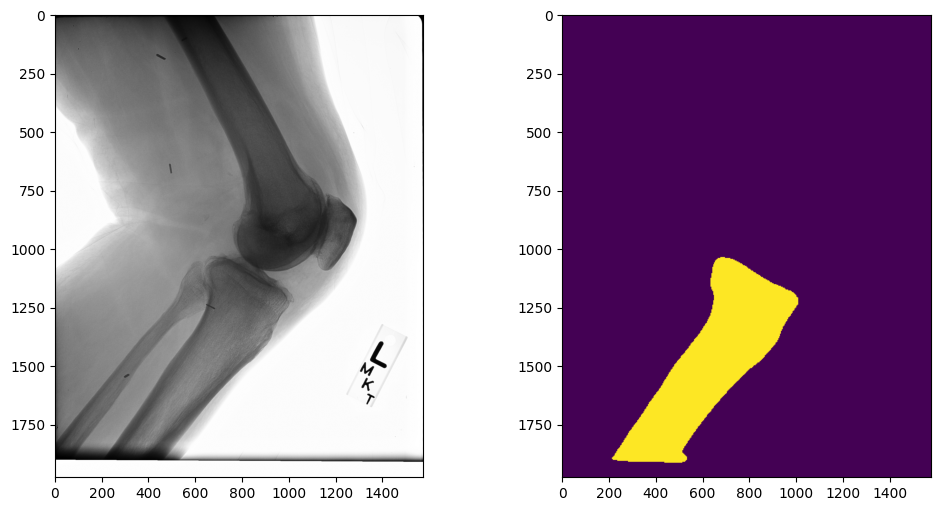

In [11]:
idx=3

testimg = pyd.dcmread(dcm_paths[idx]).pixel_array
testmask_read = sitk.ReadImage(mask_paths[idx])
testmask = sitk.GetArrayFromImage(testmask_read)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(testimg, 'gray')
ax2.imshow(testmask.squeeze(0))

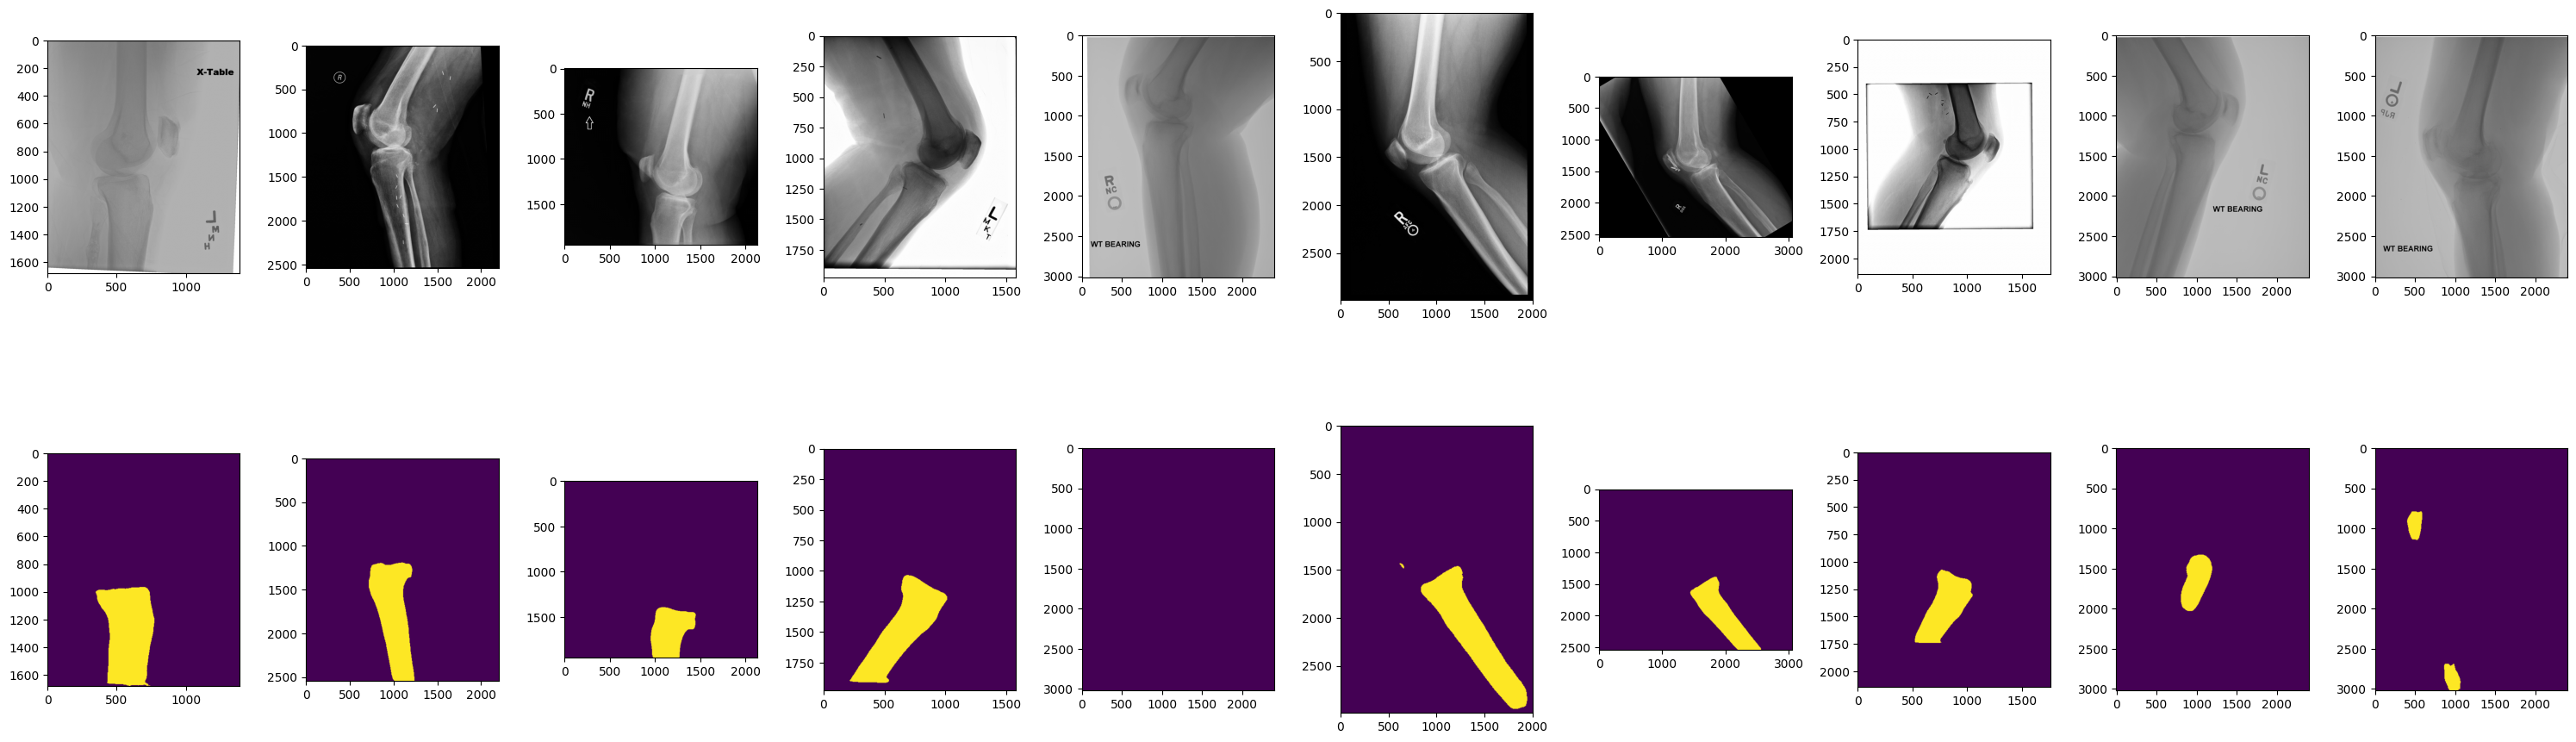

In [43]:
idx1, idx2 = 0, 10

r = range(idx1, idx2)

fig, ax = plt.subplots(2,len(r), figsize=(30, 10))

# print(list(r))
# print(ax)

for row, idx in enumerate(r):

    testimg = pyd.dcmread(dcm_paths[idx]).pixel_array
    testmask_read = sitk.ReadImage(mask_paths[idx])
    testmask = sitk.GetArrayFromImage(testmask_read)

    # print(idx)

    ax[0][row].imshow(testimg, 'gray')
    ax[1][row].imshow(testmask.squeeze(0))

plt.tight_layout()

In [ ]:
axes[2].imshow(testimg, 'gray')
axes[2].imshow(testmask.squeeze(0), alpha=0.2, cmap='Reds')
axes[2].set_title('Overlay')

In [47]:
len(dcm_paths)

50

In [51]:
round(len(dcm_paths) / 5)

10

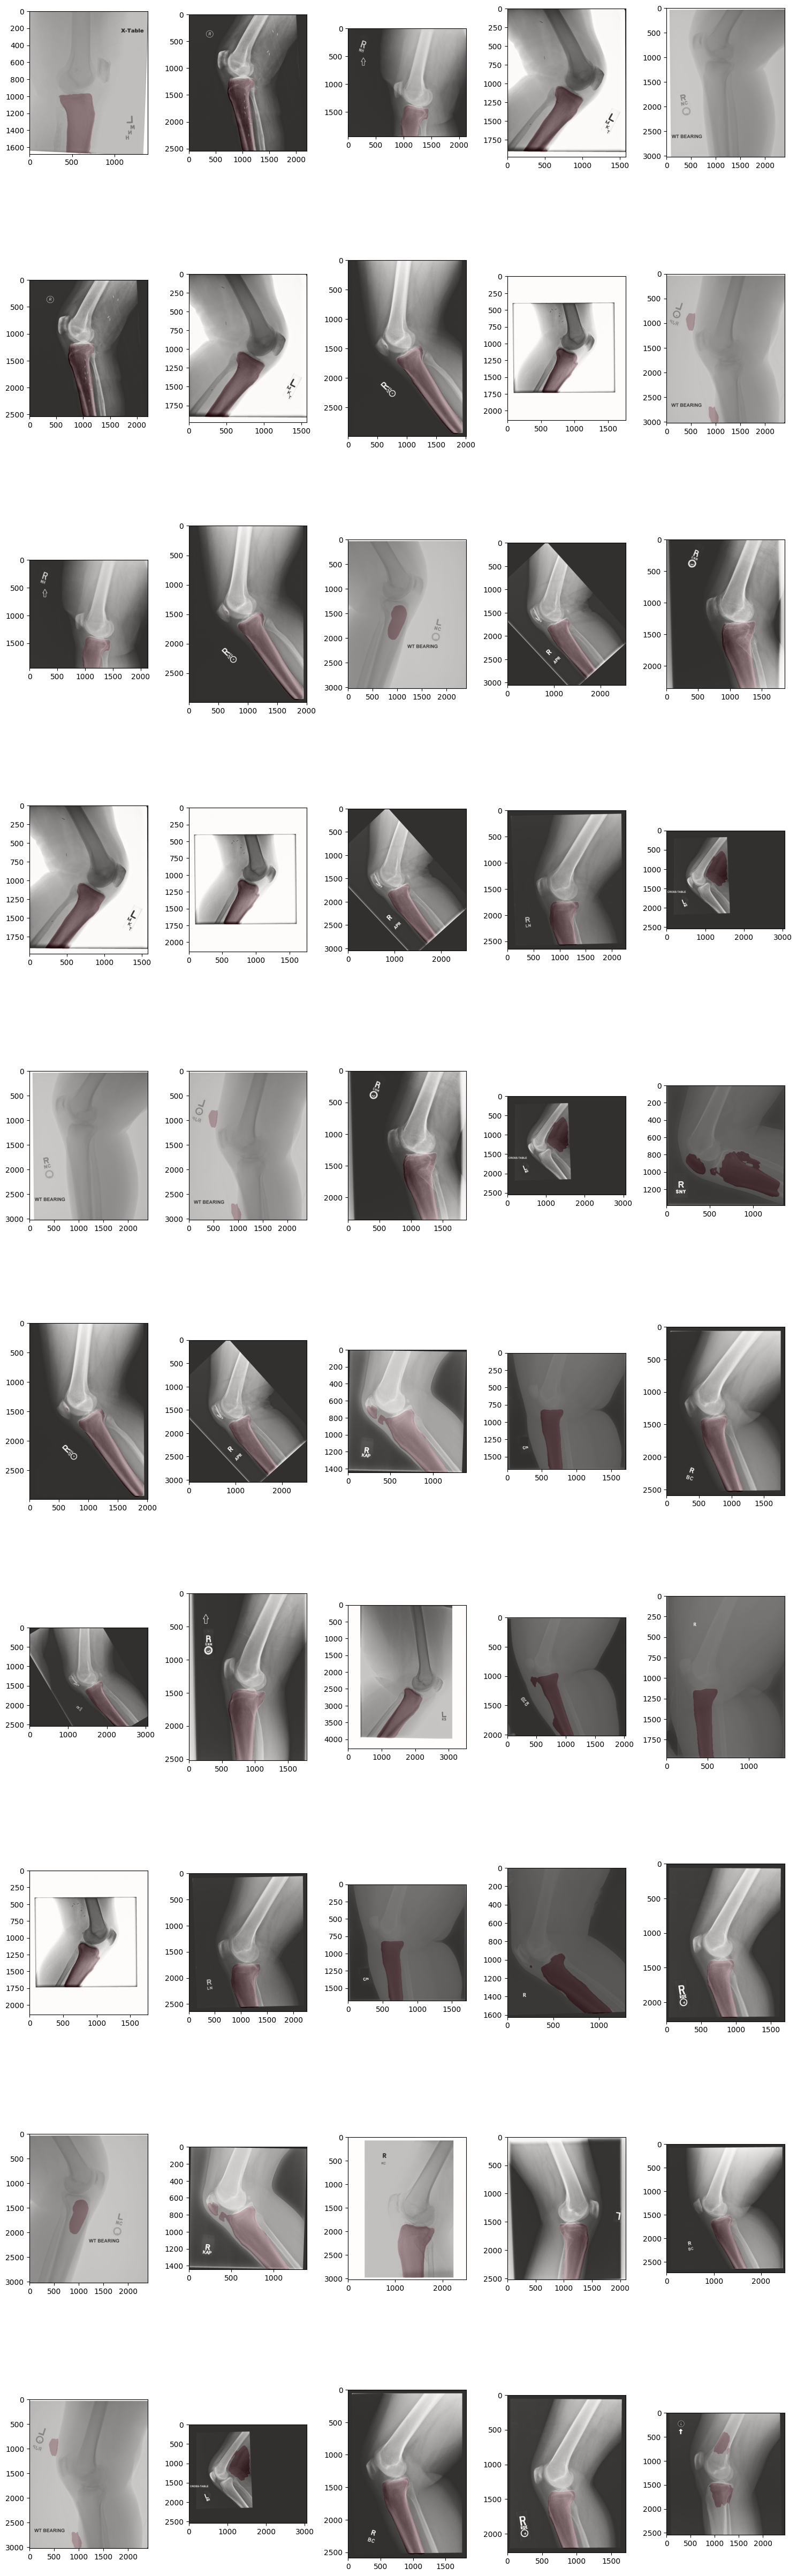

In [5]:


fig, ax = plt.subplots( round(len(dcm_paths) / 5), 5, figsize=(15, 50))

for i in range(round(len(dcm_paths) / 5)):
    for j in range(5):

        idx = (i+1)*(j+1) -1

        testimg = pyd.dcmread(dcm_paths[idx]).pixel_array
        testmask_read = sitk.ReadImage(mask_paths[idx])
        testmask = sitk.GetArrayFromImage(testmask_read)


        ax[i][j].imshow(testimg, 'gray')
        ax[i][j].imshow(testmask.squeeze(0), alpha=0.2, cmap='Reds')

plt.tight_layout()

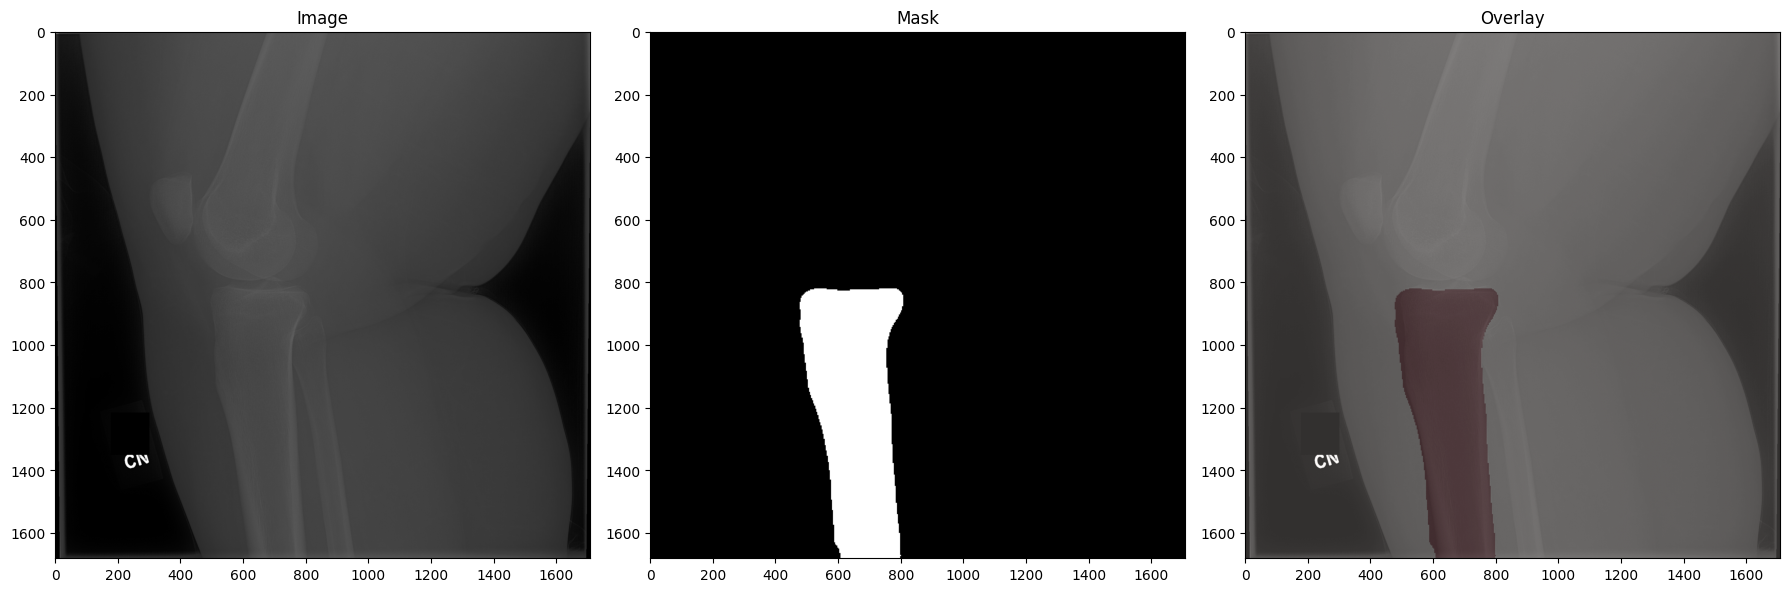

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(testimg, 'gray')
axes[0].set_title('Image')

axes[1].imshow(testmask.squeeze(0), 'gray')
axes[1].set_title('Mask')

axes[2].imshow(testimg, 'gray')
axes[2].imshow(testmask.squeeze(0), alpha=0.2, cmap='Reds')
axes[2].set_title('Overlay')

plt.tight_layout()
plt.show()

